<a href="https://colab.research.google.com/github/Gabejevans/ProjectSQL/blob/main/8_Mini_project_ML_and_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Aims of this Notebook

To investigate data on the Titanic using Machine Learning and Data Analysis methods to look at what effected survival rates of passengers

### Reading in a CSV

In [156]:
#%%writefile Mini_Python_Project.py
# import titanic dataset
import seaborn as sns; df = sns.load_dataset('titanic')
print(df)

     survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0           0       3    male  22.0      1      0   7.2500        S   Third   
1           1       1  female  38.0      1      0  71.2833        C   First   
2           1       3  female  26.0      0      0   7.9250        S   Third   
3           1       1  female  35.0      1      0  53.1000        S   First   
4           0       3    male  35.0      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
886         0       2    male  27.0      0      0  13.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   
888         0       3  female   NaN      1      2  23.4500        S   Third   
889         1       1    male  26.0      0      0  30.0000        C   First   
890         0       3    male  32.0      0      0   7.7500        Q   Third   

       who  adult_male deck  embark_town alive  alo

In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


### Initial Investigation into the data and preprocessing

In [158]:
#better understand the numeric data, we want to use the describe() method. this gives us an idea of the central tendancies
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [159]:
# split into numeric and categorical variables
df_num = df[['age', 'sibsp', 'parch', 'fare']]
df_cat = df[['survived', 'pclass', 'sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']]

In [160]:
print(df_num)

      age  sibsp  parch     fare
0    22.0      1      0   7.2500
1    38.0      1      0  71.2833
2    26.0      0      0   7.9250
3    35.0      1      0  53.1000
4    35.0      0      0   8.0500
..    ...    ...    ...      ...
886  27.0      0      0  13.0000
887  19.0      0      0  30.0000
888   NaN      1      2  23.4500
889  26.0      0      0  30.0000
890  32.0      0      0   7.7500

[891 rows x 4 columns]


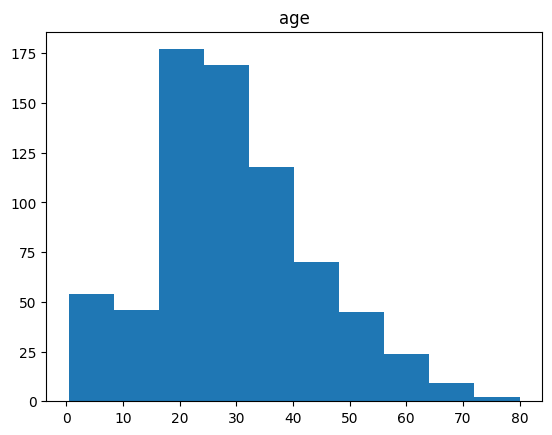

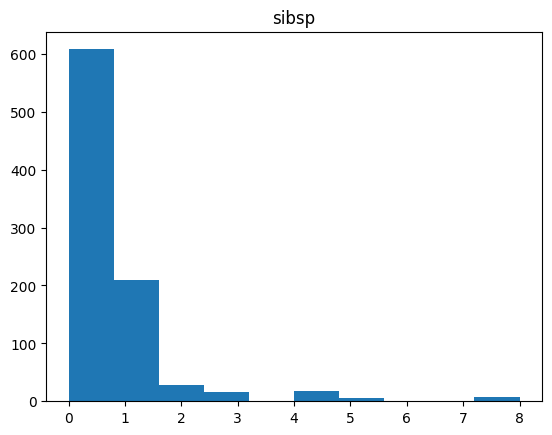

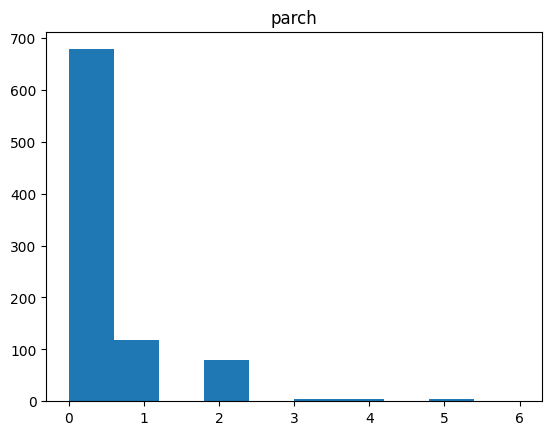

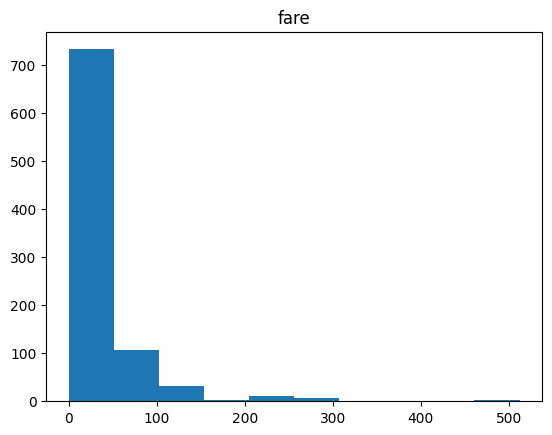

In [161]:
#Creat histograms of the numbered features
import matplotlib.pyplot as plt

for i in df_num.columns:
  plt.hist(df_num[i])
  plt.title(i)
  plt.show()

Only the age from these numeric data types follows a somewhat normal distributiion. Noramlise then scale

            age     sibsp     parch      fare
age    1.000000 -0.308247 -0.189119  0.096067
sibsp -0.308247  1.000000  0.414838  0.159651
parch -0.189119  0.414838  1.000000  0.216225
fare   0.096067  0.159651  0.216225  1.000000


<Axes: >

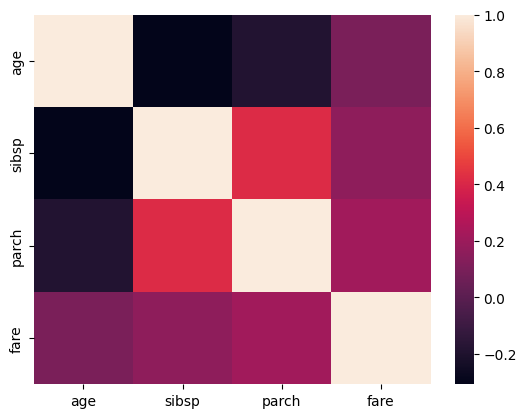

In [162]:
# look at a heatmap of numeric features
print(df_num.corr())
sns.heatmap(df_num.corr())

age children has a negative correlation
number of sibsp and parch are highly correlataed
parch/fare somewhat correlated

In [163]:
#compare survival rate across Age, SibSp, ParCh and Fare
import pandas as pd
import numpy as np

pd.pivot_table(df, index=['survived'], values = ['age', 'sibsp', 'parch', 'fare'])

,age,fare,parch,sibsp
survived,,,,
0,30.626179,22.117887,0.329690,0.553734
1,28.343690,48.395408,0.464912,0.473684


Do a similar thing with the catergorical data

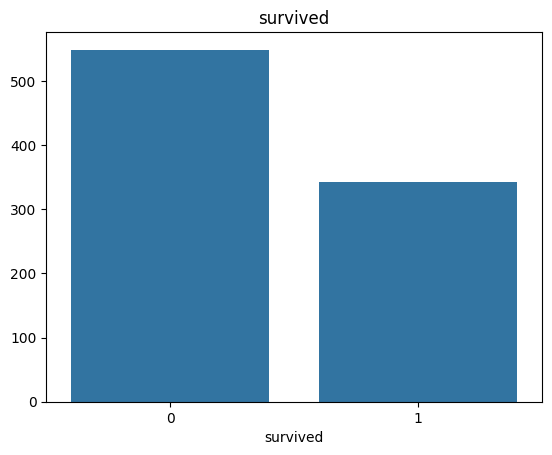

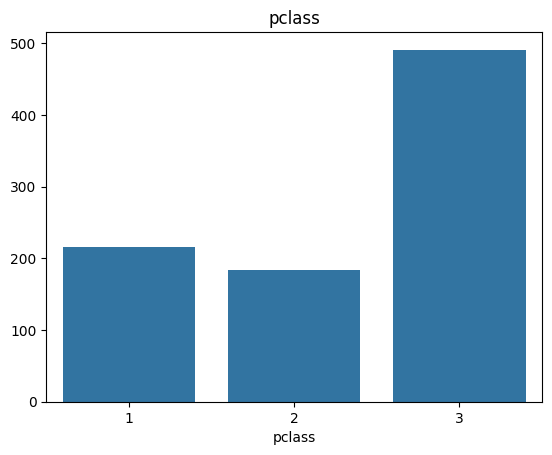

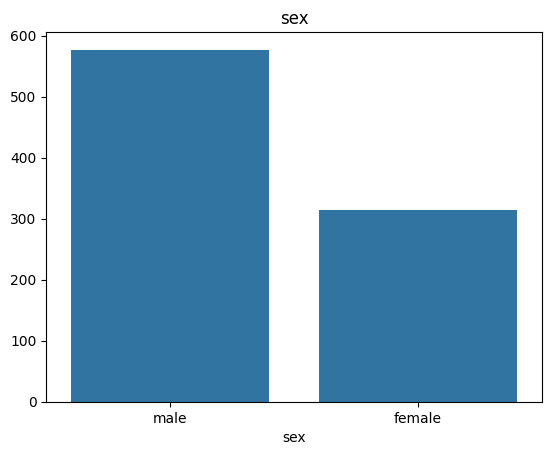

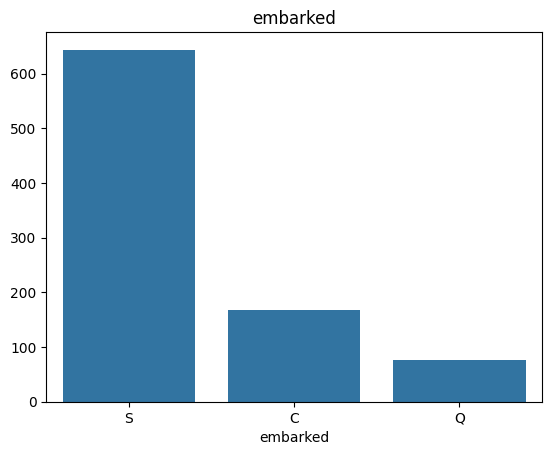

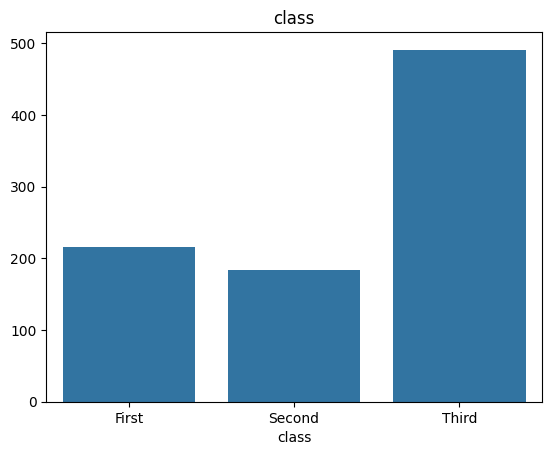

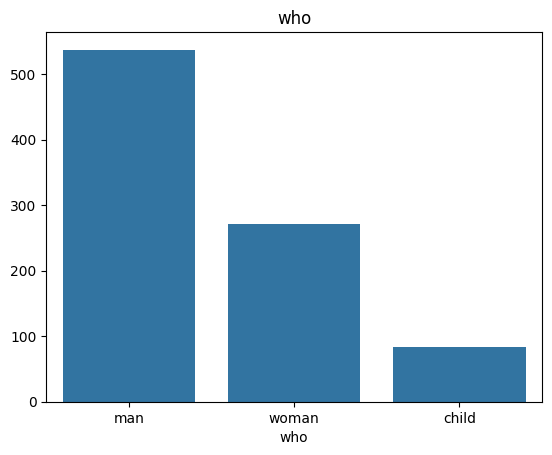

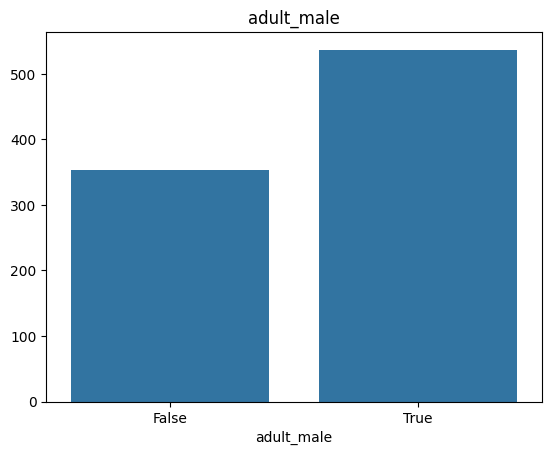

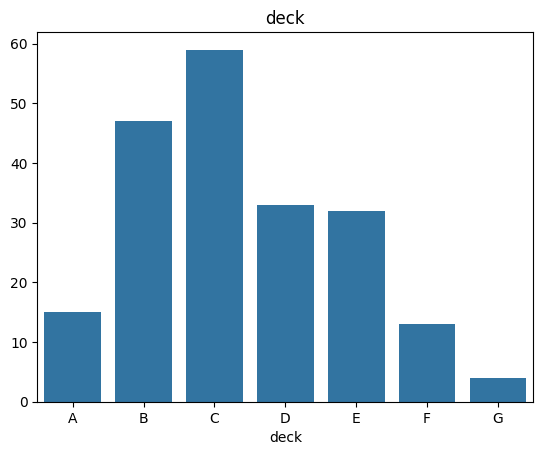

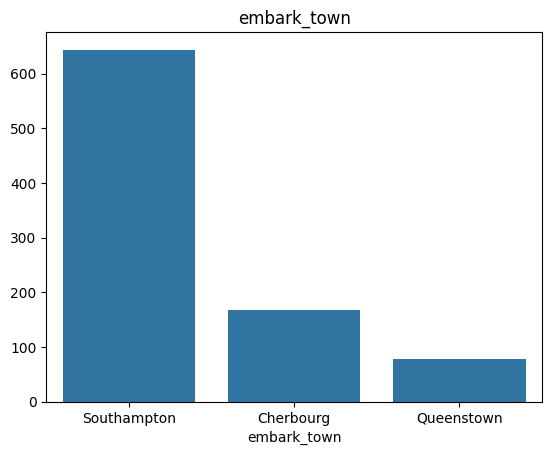

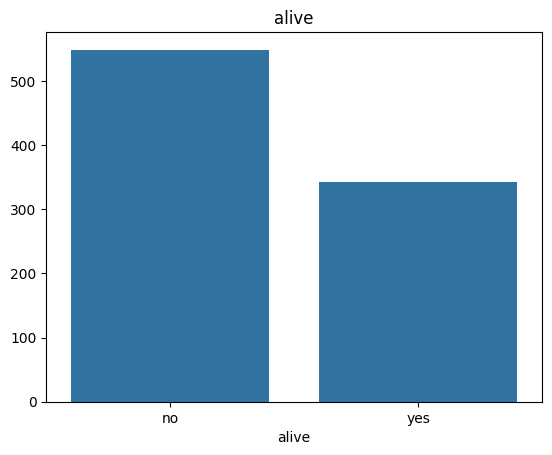

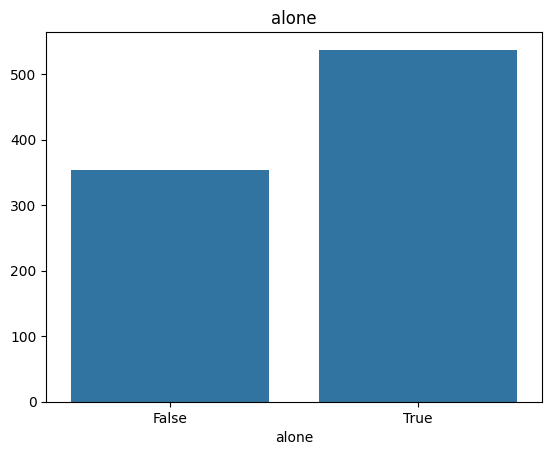

In [164]:
#create barplots for each categorical feature
for i in df_cat.columns:
  sns.barplot(x=df_cat[i].value_counts().index, y=df_cat[i].value_counts().values).set_title(i)
  plt.show()

### Data Editing

So we can see now there's some repeat columns i.e class and survived so we should remove these from the categorical dataset

dont see ticket and cabin here - must just be a slightly different dataset to the video

In [165]:
#check that data is identical for the class/pclass and survived/alive

# Map 'alive' to match survived's 0/1 format, then compare
matches = (df_cat['alive'].map({'yes': 1, 'no': 0}) == df_cat['survived'])
print(matches.all())  # True if every row matches

#do the same thing for the class
matches = (df_cat['pclass'].map({1: 'First', 2: 'Second', 3: 'Third'}) == df_cat['class'])
print(matches.all())

True
True


They are both identical so remove one of each, i'm going to keep pclass and survived because they are formatted numerically

In [166]:
df_cat = df_cat.drop(['class', 'alive', 'embark_town', 'adult_male'], axis=1)

Look into the data vs survived using pivot tables

In [167]:
print(pd.pivot_table(df_cat, index=['survived'], columns=['pclass'], values = 'who', aggfunc='count'))
print()
print(pd.pivot_table(df_cat, index=['survived'], columns=['who'], values = 'pclass', aggfunc='count'))
print()
print(pd.pivot_table(df_cat, index=['survived'], columns=['alone'], values = 'who', aggfunc='count'))
print()
print(pd.pivot_table(df_cat, index=['survived'], columns=['embarked'], values = 'who', aggfunc='count'))
print()
print(pd.pivot_table(df_cat, index='survived', columns='deck', values = 'who', aggfunc='count', observed = True))

pclass      1   2    3
survived              
0          80  97  372
1         136  87  119

who       child  man  woman
survived                   
0            34  449     66
1            49   88    205

alone     False  True 
survived              
0           175    374
1           179    163

embarked   C   Q    S
survived             
0         75  47  427
1         93  30  217

deck      A   B   C   D   E  F  G
survived                         
0         8  12  24   8   8  5  2
1         7  35  35  25  24  8  2


In [168]:
#including the nulls in the cabin
df_cat['deck'] = df_cat['deck'].cat.add_categories('Missing').fillna('Missing')

pivot = pd.pivot_table(df_cat, index='survived', columns='deck', values='who', aggfunc='count', observed=True)
print(pivot)

deck      A   B   C   D   E  F  G  Missing
survived                                  
0         8  12  24   8   8  5  2      482
1         7  35  35  25  24  8  2      206


Notes:
first class had a higher tendency to survive, so did woman/children.

lots of data is missing from the deck data, more values proportionally for survived than dead, this could skew its meaningfullness

we also dont need adult man as this is in the gender/child splits

next steps: see if there is any test data or if we need to create it.
run through the steps for a machine learning analysis.

### Machine learning analysis:

In [169]:
#encoding the categorical data to prepare it for machine learning model
df_cat_encoded = pd.get_dummies(df_cat, drop_first = True)
#print(df_cat_encoded)

#combine with numerical data
df_combined = pd.concat([df_num, df_cat_encoded], axis =1)

#print(df_combined)

Improving the data points:

Fare price: the fare price is a heavily right skewed distribution. Log norming the fare price will compress the larger values making the distributio more symetric. this is important for linear/logistic regression models and distance ased models.


<Axes: >

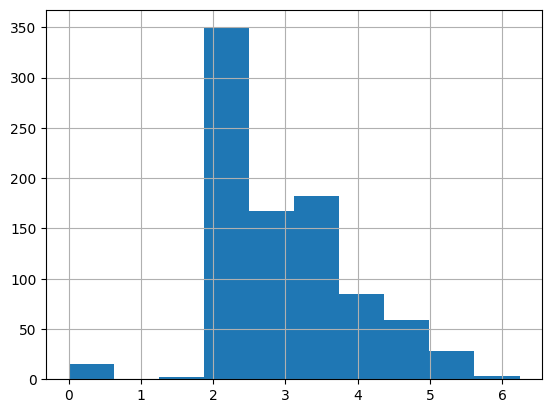

In [170]:
#Log norming fare date
df_combined['norm_fare'] = np.log(df_combined.fare+1)
df_combined['norm_fare'].hist()


In [171]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           714 non-null    float64
 1   sibsp         891 non-null    int64  
 2   parch         891 non-null    int64  
 3   fare          891 non-null    float64
 4   survived      891 non-null    int64  
 5   pclass        891 non-null    int64  
 6   alone         891 non-null    bool   
 7   sex_male      891 non-null    bool   
 8   embarked_Q    891 non-null    bool   
 9   embarked_S    891 non-null    bool   
 10  who_man       891 non-null    bool   
 11  who_woman     891 non-null    bool   
 12  deck_B        891 non-null    bool   
 13  deck_C        891 non-null    bool   
 14  deck_D        891 non-null    bool   
 15  deck_E        891 non-null    bool   
 16  deck_F        891 non-null    bool   
 17  deck_G        891 non-null    bool   
 18  deck_Missing  891 non-null    

We still have null values in the age data catagory, fixes:

- use a model that excepts nulls i.e HistGradientBoosting
- make a prediction on age using another model and fill in the gaps
- put in median age (seems like a weak approach)

In [172]:
# Calculating age then filling in gaps
from sklearn.impute import KNNImputer

# create two datasets, 1 for hist and one for other models
df_combined_filled = df_combined.copy()

#using KNN Imputer to fill age based on similar passengers
imputer = KNNImputer(n_neighbors=5)
df_combined_filled[['age']] = imputer.fit_transform(df_combined[['age']])

df_combined_filled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           891 non-null    float64
 1   sibsp         891 non-null    int64  
 2   parch         891 non-null    int64  
 3   fare          891 non-null    float64
 4   survived      891 non-null    int64  
 5   pclass        891 non-null    int64  
 6   alone         891 non-null    bool   
 7   sex_male      891 non-null    bool   
 8   embarked_Q    891 non-null    bool   
 9   embarked_S    891 non-null    bool   
 10  who_man       891 non-null    bool   
 11  who_woman     891 non-null    bool   
 12  deck_B        891 non-null    bool   
 13  deck_C        891 non-null    bool   
 14  deck_D        891 non-null    bool   
 15  deck_E        891 non-null    bool   
 16  deck_F        891 non-null    bool   
 17  deck_G        891 non-null    bool   
 18  deck_Missing  891 non-null    

Choosing some models:

*   Logistic Regression
*   Random Forest Classifier



In [173]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

#create the models

model_linear = LogisticRegression(max_iter = 1000)
model_forest = RandomForestClassifier(random_state = 42)
model_hist = HistGradientBoostingClassifier(random_state = 42)

In [174]:
from sklearn.model_selection import train_test_split

# wrap into a function for the two daasets

def split_data(df):

    X = df.drop('survived', axis=1)
    y = df['survived']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    return X_train, X_test, y_train, y_test

In [175]:
X_train, X_test, y_train, y_test = split_data(df_combined_filled)
X_train_hist, X_test_hist, y_train_hist, y_test_hist = split_data(df_combined)

In [176]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 19)
(179, 19)
(712,)
(179,)


Train the models

In [177]:
model_linear.fit(X_train, y_train)
model_forest.fit(X_train, y_train)
model_hist.fit(X_train_hist, y_train_hist)

HistGradientBoostingClassifier(random_state=42)

Make some predictions

In [178]:
predictions_linear = model_linear.predict(X_test)
predictions_forest = model_forest.predict(X_test)
predictions_hist = model_hist.predict(X_test_hist)

Print the accuracy of the predictions

In [179]:
from sklearn.metrics import accuracy_score

accuracy_linear = accuracy_score(y_test, predictions_linear)
accuracy_forest = accuracy_score(y_test, predictions_forest)
accuracy_hist = accuracy_score(y_test_hist, predictions_hist)
print(f"Accuracy Logistic Regression: {accuracy_linear:.3f}")
print(f"Accuracy Random Forest: {accuracy_forest:.3f}")
print(f"Accuracy HistGradientBoost: {accuracy_hist: .3f}")

Accuracy Logistic Regression: 0.821
Accuracy Random Forest: 0.799
Accuracy HistGradientBoost:  0.816


The Predictions:

- Pretty good accuracy seen across all models at around 80%

Cross Validation:

Voting Classifier

In [180]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(estimators=[
    ('lr', model_linear),
    ('rf', model_forest),
    ('hgb', model_hist)
], voting='soft')

ensemble.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(max_iter=1000)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('hgb',
                              HistGradientBoostingClassifier(random_state=42))],
                 voting='soft')

Feature Importances:

In [181]:
from sklearn.inspection import permutation_importance

result = permutation_importance(ensemble, X_test, y_test, n_repeats=10, random_state=42)

importances = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result.importances_mean
}).sort_values('importance', ascending=False)

print(importances)

         feature    importance
9        who_man  9.497207e-02
4         pclass  3.854749e-02
0            age  1.731844e-02
14        deck_E  1.229050e-02
3           fare  8.379888e-03
10     who_woman  6.703911e-03
2          parch  5.586592e-03
5          alone  5.027933e-03
6       sex_male  2.234637e-03
16        deck_G  5.586592e-04
7     embarked_Q  5.586592e-04
18     norm_fare  2.220446e-17
15        deck_F  0.000000e+00
12        deck_C -5.586592e-04
8     embarked_S -1.675978e-03
17  deck_Missing -1.675978e-03
11        deck_B -1.675978e-03
1          sibsp -3.351955e-03
13        deck_D -6.145251e-03


In [182]:
# Map each dummy column back to its original feature name
def get_original_feature(col_name):
    for prefix in ['deck_', 'embarked_', 'who_', 'sex_']:
        if col_name.startswith(prefix):
            return prefix.rstrip('_')
    return col_name  # leave non-dummy columns (age, fare, etc.) as-is

importances['original_feature'] = importances['feature'].apply(get_original_feature)

grouped_importances = importances.groupby('original_feature')['importance'].sum().sort_values(ascending=False)

print(grouped_importances)

original_feature
who          1.016760e-01
pclass       3.854749e-02
age          1.731844e-02
fare         8.379888e-03
parch        5.586592e-03
alone        5.027933e-03
deck         2.793296e-03
sex          2.234637e-03
norm_fare    2.220446e-17
embarked    -1.117318e-03
sibsp       -3.351955e-03
Name: importance, dtype: float64


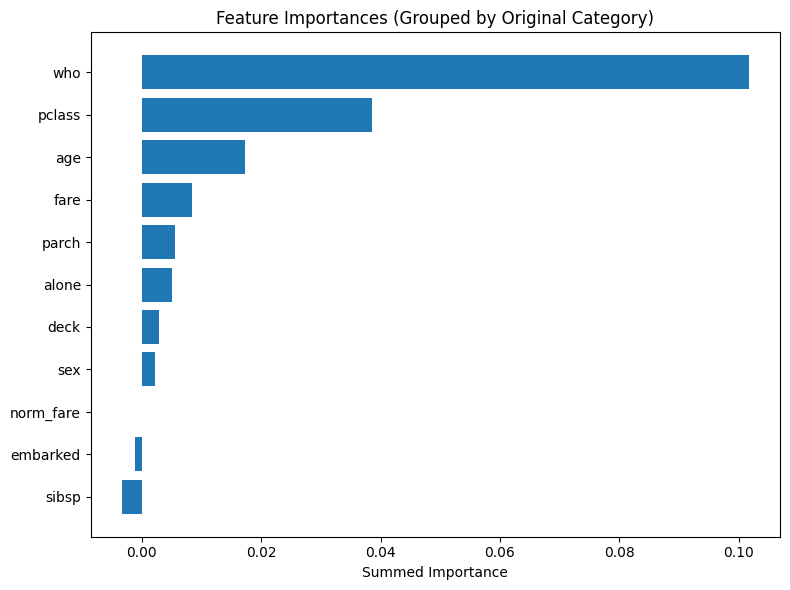

In [183]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.barh(grouped_importances.index, grouped_importances.values)
plt.xlabel('Summed Importance')
plt.title('Feature Importances (Grouped by Original Category)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

We can see from the model that 'who' (child, adult man, adult women) and class had by far the biggest weighting on the survival rate: lets try and pull more analysis out of that i.e. what gender/what class.

Age was also a factor along with ticket, however ticket price and class are expected to be somewhat linked.

### General Further Analysis:

#### Direct Group Comparisons:

In [184]:
# Survival rate by who + pclass combined
df_cat.groupby(['who', 'pclass'])['survived'].mean().unstack()

pclass,1,2,3
who,,,
child,0.833333,1.000000,0.431034
man,0.352941,0.080808,0.119122
woman,0.978022,0.909091,0.491228


We can see that although it was true that gender played a in role in survival, the class of the people who survived is just as important with 97% of 1st class woman surviving and only 49% of third class. The drop off for men is proportionally even larger with around 12% of 3rd class men surviving vs 1st classes 35%.
this is exascerbated when we consider the size of each class.

In [185]:
class_who_counts = df_cat.groupby(['pclass', 'who']).size()
print(class_who_counts)

pclass  who  
1       child      6
        man      119
        woman     91
2       child     19
        man       99
        woman     66
3       child     58
        man      319
        woman    114
dtype: int64


In [186]:
third_class_men = class_who_counts[3,'man']
print(third_class_men)
print(f"Third class men made up {third_class_men*100/891:.3g}% of passengers")


319
Third class men made up 35.8% of passengers


In [187]:
third_class_men_deaths = df_cat[(df_cat['pclass'] == 3) & (df_cat['who'] == 'man') & (df_cat['survived'] == 0)].shape[0]
total_deaths = df_cat[df_cat['survived'] == 0].shape[0]
third_class_men_death_rate = third_class_men_deaths / total_deaths
print("With such a low survival rate of around 12%")
print(f"{third_class_men_deaths} men with third class tickets died")
print(f"accounting for {third_class_men_death_rate*100:.3g}% of the total deaths")

With such a low survival rate of around 12%
281 men with third class tickets died
accounting for 51.2% of the total deaths


It's clear that the majority of the loss of life is attributed to just the third class male group, showing that they were dissproportionately affected as they only made up around 35.8% of the ships total. Meaning there death toll was around 15.4 percentage points higher than expected.

<Axes: xlabel='pclass', ylabel='age'>

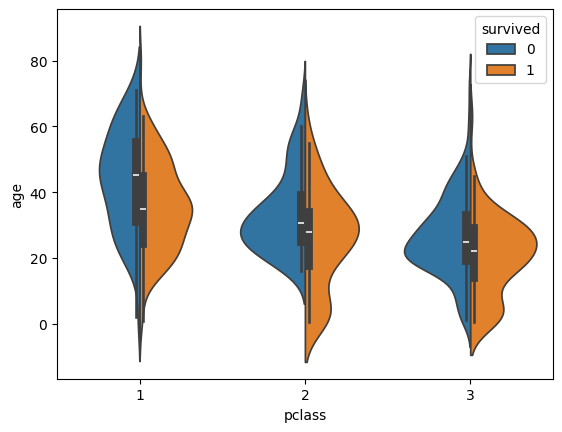

In [188]:
import seaborn as sns
sns.violinplot(data=df_combined, x='pclass', y='age', hue='survived', split=True)

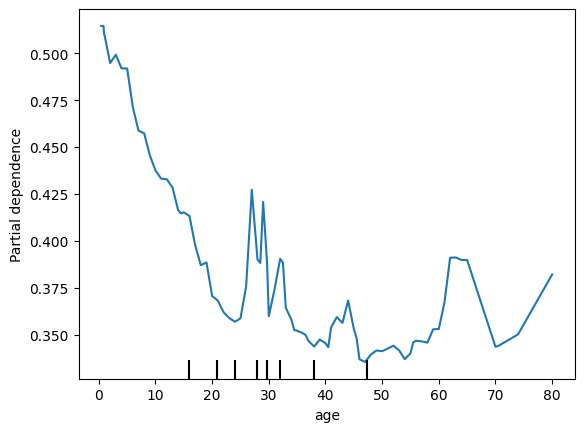

In [189]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(model_forest, X_train, features=['age'])

#### Partial Dependence Display from ensembled model Age vs. Class

showing a colour coded survival chance countouring against 2 variables (class and age)

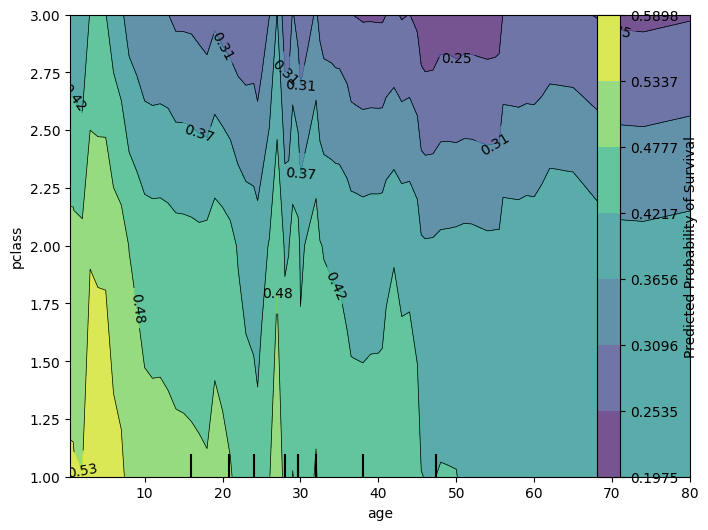

In [190]:
fig, ax = plt.subplots(figsize=(8, 6))
display = PartialDependenceDisplay.from_estimator(ensemble, X_train, features=[('age', 'pclass')], ax=ax)

plt.colorbar(display.contours_[0][0], ax=ax, label='Predicted Probability of Survival')
plt.show()

General trend is younger and higher class increased chances of survival.

Possible reasons:

- Tendency to save children over adults is a common human reaction/protocol during a crisis.
- people with more wealth prioritised as socially they were deeemed of more value and had more power to control who enetered the lifeboats.

(50, 19, 2)


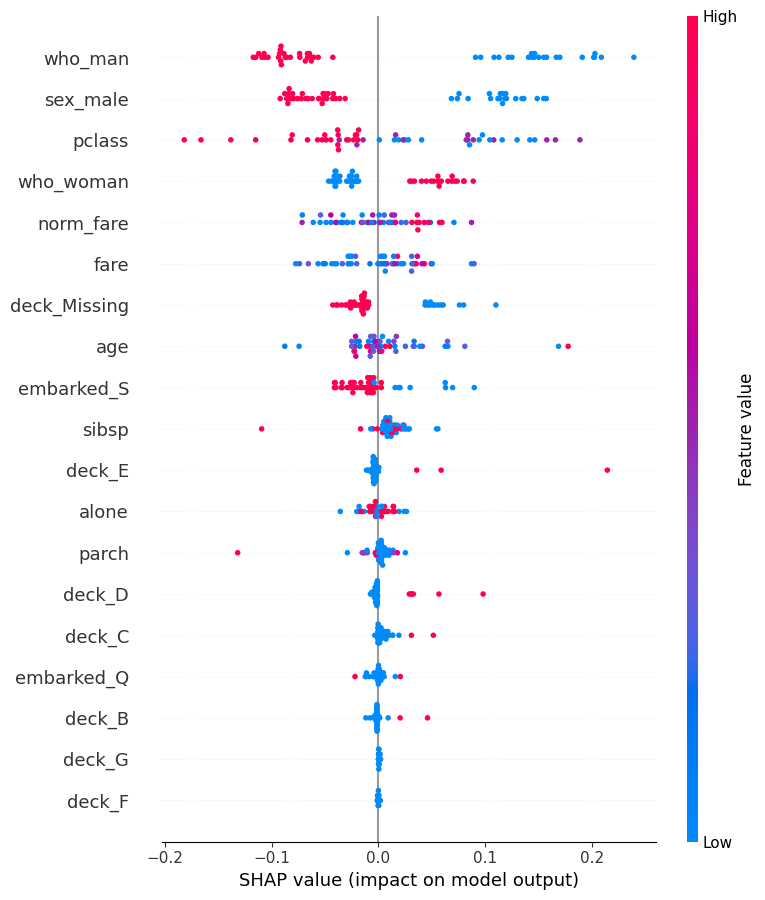

In [191]:
!pip install shap --quiet
import shap

X_sample = X_test.sample(50, random_state=42)
explainer = shap.TreeExplainer(model_forest)
shap_values = explainer.shap_values(X_sample)
print(np.array(shap_values).shape)
#print(X_test.sample(50, random_state=42).shape)
shap.summary_plot(shap_values[:, :, 1], X_sample)

### Focussed Analysis

#### Family Size

Small dive into Family Size vs. Survival:

In [192]:
#calculate the new feature family size
df_combined['family_size'] = df_combined['sibsp'] + df_num['parch'] + 1

In [193]:
#raw family survival rate by family size
print(df_combined.groupby('family_size')['survived'].mean())

family_size
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: survived, dtype: float64


In [194]:
#putting family sizes into categories alone, small, large
def family_size_category(size):
    if size == 1:
        return 'Alone'
    elif size <= 4:
        return 'Small'
    else:
        return 'Large'

df_combined['family_category'] = df_combined['family_size'].apply(family_size_category)

print(df_combined.groupby('family_category')['survived'].agg(['mean', 'count']))

                     mean  count
family_category                 
Alone            0.303538    537
Large            0.161290     62
Small            0.578767    292


The results clearly show that larger families struggled to survive the most, whilst people travellig alone also fell below the average of 38%. Small families on the otherhand were at a surviva rate of 20% above the average.

possible reasons:

- Easier to look after and look out for a smaller family, with two parents being able to save their child or a couple children over themselves
- solo travellers would have had less support and coordination during the evacuation
- larger families pose a bigger logistical challenge

### Model Performance:

In [195]:
#get predictions and line them up with actual outcomes
predictions = ensemble.predict(X_test)

results = X_test.copy()
results['actual'] = y_test
results['predicted'] = predictions
results['correct'] = results['actual'] == results['predicted']

In [196]:
#Isolate the missclassified passengers
misclassified = results[results['correct'] == False]
print(f"Number of misclassified passengers: {len(misclassified)} out of {len(results)}")
#print(misclassified)

Number of misclassified passengers: 31 out of 179


In [197]:
#Split int two types of errors
# Model predicted survived, but they actually died
false_positives = misclassified[(misclassified['predicted'] == 1) & (misclassified['actual'] == 0)]

# Model predicted died, but they actually survived
false_negatives = misclassified[(misclassified['predicted'] == 0) & (misclassified['actual'] == 1)]

print(f"Predicted survival, but died: {len(false_positives)}")
print(f"Predicted death, but survived: {len(false_negatives)}")

Predicted survival, but died: 12
Predicted death, but survived: 19


the 19 people here who survived represent people who looked doomed from the models predictions but somehow managed to survive.

whereas the 12 who were predicted survival had all the advantages but still died

this points to the unpredictability of the disaster, beyond demographics

In [198]:
#look at the profile of each error type
print("Passengers model expected to SURVIVE, but died:")
print(false_positives[['pclass', 'age', 'fare']].describe())

print("\nPassengers model expected to DIE, but survived:")
print(false_negatives[['pclass', 'age', 'fare']].describe())

Passengers model expected to SURVIVE, but died:
          pclass        age        fare
count  12.000000  12.000000   12.000000
mean    2.333333  37.683260   24.465275
std     0.778499  14.535070   29.048697
min     1.000000   9.000000    7.550000
25%     2.000000  30.299779    9.838550
50%     2.500000  35.000000   15.372900
75%     3.000000  47.000000   26.000000
max     3.000000  58.000000  113.275000

Passengers model expected to DIE, but survived:
          pclass        age       fare
count  19.000000  19.000000  19.000000
mean    2.105263  31.289241  27.236621
std     0.994135   8.853348  17.647549
min     1.000000  15.000000   7.854200
25%     1.000000  28.849559  13.727100
50%     3.000000  29.699118  26.550000
75%     3.000000  36.500000  33.443750
max     3.000000  48.000000  63.358300


In [199]:
print("Predicted survival, but died (n=12) — % male:")
print(f"{false_positives['sex_male'].mean() * 100: .3g}")

print("\nPredicted death, but survived (n=19) — % male:")
print(f"{false_negatives['sex_male'].mean() * 100: .3g}")

Predicted survival, but died (n=12) — % male:
 16.7

Predicted death, but survived (n=19) — % male:
 78.9


we can see here the gender split of the predictions, highighting that being be male is  a feature doing the heavy lifting in the model. This is in agreement with the analysis done on class and sex earlier. It has confirmed that the model has learned gender as a near deterministic rule for deciding survival chances. The cases where it has failed represent where real world individual circumstances overrode the broader demographic trend.

In [200]:
print(X_test.columns.tolist())

['age', 'sibsp', 'parch', 'fare', 'pclass', 'alone', 'sex_male', 'embarked_Q', 'embarked_S', 'who_man', 'who_woman', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_Missing', 'norm_fare']


In [201]:
#get confidence scores for these errors
probabilities = ensemble.predict_proba(X_test)[:, 1]  # probability of survival
results['probability'] = probabilities

# Show the most confident wrong predictions
misclassified_with_prob = results[results['correct'] == False].sort_values('probability', ascending=False)
print(misclassified_with_prob[['pclass', 'age', 'fare', 'who_man', 'actual', 'predicted', 'probability']].head(10))

     pclass        age     fare  who_man  actual  predicted  probability
772       2  57.000000  10.5000    False       0          1     0.945257
357       2  38.000000  13.0000    False       0          1     0.920459
854       2  44.000000  26.0000    False       0          1     0.915316
312       2  26.000000  26.0000    False       0          1     0.898648
657       3  32.000000  15.5000    False       0          1     0.790414
396       3  31.000000   7.8542    False       0          1     0.713033
235       3  29.699118   7.5500    False       0          1     0.685752
767       3  30.500000   7.7500    False       0          1     0.661767
254       3  41.000000  20.2125    False       0          1     0.661356
852       3   9.000000  15.2458    False       0          1     0.620280


All the top failures of the model were woman or children, signifying it was very out of the norm for women and children to die proportionally. this is due to this display leaning on probability to rank. if we look at the difference between probability and result it will give us a combined greatest outliers table


In [202]:
results['error_magnitude'] = abs(results['probability'] - results['actual'])

In [203]:
results['error_magnitude'] = abs(results['probability'] - results['actual'])

worst_failures = results.sort_values('error_magnitude', ascending=False)

print(worst_failures[['pclass', 'age', 'fare', 'who_man', 'actual', 'predicted', 'probability', 'error_magnitude']].head(10))


     pclass        age     fare  who_man  actual  predicted  probability  \
772       2  57.000000  10.5000    False       0          1     0.945257   
338       3  45.000000   8.0500     True       1          0     0.075001   
286       3  30.000000   9.5000     True       1          0     0.079530   
357       2  38.000000  13.0000    False       0          1     0.920459   
854       2  44.000000  26.0000    False       0          1     0.915316   
65        3  29.699118  15.2458     True       1          0     0.097310   
709       3  29.699118  15.2458     True       1          0     0.097310   
312       2  26.000000  26.0000    False       0          1     0.898648   
25        3  38.000000  31.3875    False       1          0     0.129581   
673       2  31.000000  13.0000     True       1          0     0.129706   

     error_magnitude  
772         0.945257  
338         0.924999  
286         0.920470  
357         0.920459  
854         0.915316  
65          0.902690  
70

### Checking the effect of Fare on the total amount

- fair showed a minor indicator in the model but this may have been overshadowed by the gender skewing seen.

- maybe looking at a correlation of fares in each gender will reveal more

In [204]:
#checking the correlation
print(df_combined[['fare', 'survived']].corr())

              fare  survived
fare      1.000000  0.257307
survived  0.257307  1.000000


This shows a moderate positive correlation

In [205]:
#Fare - survival correlation
for pclass in [1, 2, 3]:
    subset = df_combined[df_combined['pclass'] == pclass]
    corr = subset['fare'].corr(subset['survived'])
    print(f"Class {pclass} fare-survival correlation: {corr:.3g}, n={len(subset)}")

Class 1 fare-survival correlation: 0.191, n=216
Class 2 fare-survival correlation: 0.0986, n=184
Class 3 fare-survival correlation: 0.00093, n=491


we can see here a slight correlation within the first class of fare paid and survival rates, half this correlation was seen in the second class. the third class show now real correlation.

The

possible reasons:

- highest paying passengers in the first class were in fact modestly prioritised, correlation squared = varience in survival (so we're looing roughly 3-4% in varience
- this effect was half seen in the second class implying they also had a bit of a sway
- thrid class passengers seemed to have all been in a similar situation i.e. access to life boats

In [206]:
#looking at the split b
for sex in [0, 1]:
    for pclass in [1, 2, 3]:
        subset = df_combined[(df_combined['pclass'] == pclass) & (df_combined['sex_male'] == sex)]
        if len(subset) > 5:
            corr = subset['fare'].corr(subset['survived'])
            print(f"Class {pclass}, sex_male={sex}: fare-survival correlation = {corr:.3g}, n={len(subset)}")

Class 1, sex_male=0: fare-survival correlation = -0.011, n=94
Class 2, sex_male=0: fare-survival correlation = 0.101, n=76
Class 3, sex_male=0: fare-survival correlation = -0.314, n=144
Class 1, sex_male=1: fare-survival correlation = 0.0734, n=122
Class 2, sex_male=1: fare-survival correlation = 0.0394, n=108
Class 3, sex_male=1: fare-survival correlation = 0.099, n=347


this data shows that there was no real correlation in the first class and that fares of women may have just been a bit higher.

the conclusion has to be that higher fair didn't play a large role.

we do see a somewhat stronger negative correlation with 3rd class women, suggesting higher fare payers were in a worse position to get to life boats.

In [207]:
#confirmation of female and male mean price in first class
print(df_combined[df_combined['pclass'] == 1].groupby('sex_male')['fare'].mean())


sex_male
False    106.125798
True      67.226127
Name: fare, dtype: float64


female first class tickets were significantly higher.

### Deck and Cabin location

In [208]:
#
print(pd.crosstab(df_cat['pclass'], df_cat['deck'].isnull()))

deck    False
pclass       
1         216
2         184
3         491


In [209]:
#compare survival rate - known vs deck
df_cat['has_deck'] = df_cat['deck'] != 'Missing'
print(df_cat.groupby('has_deck')['survived'].mean())

has_deck
False    0.299419
True     0.669951
Name: survived, dtype: float64


a much higher proportion of people with their deck recorded survived, is deck recording another proxy for wealth?

In [210]:
#class vs mean
print(df_cat.groupby('pclass', observed = True)['has_deck'].mean())

pclass
1    0.810185
2    0.086957
3    0.024440
Name: has_deck, dtype: float64


We can clearly see here that 80% of first class passengers had recorded deck confirming that deck recording and wealth went hand in hand.

In [211]:
#survival by specific deck
known_deck = df_cat[df_cat['deck'] != 'Missing']
print(known_deck.groupby('deck', observed = False)['survived'].agg(['mean', 'count']))

             mean  count
deck                    
A        0.466667     15
B        0.744681     47
C        0.593220     59
D        0.757576     33
E        0.750000     32
F        0.615385     13
G        0.500000      4
Missing       NaN      0


In [212]:
for pclass in known_deck['pclass'].unique():
    subset = known_deck[known_deck['pclass'] == pclass]
    print(f"\nClass {pclass}:")
    print(subset.groupby('deck', observed = False)['survived'].agg(['mean', 'count']))


Class 1:
             mean  count
deck                    
A        0.466667     15
B        0.744681     47
C        0.593220     59
D        0.758621     29
E        0.720000     25
F             NaN      0
G             NaN      0
Missing       NaN      0

Class 3:
         mean  count
deck                
A         NaN      0
B         NaN      0
C         NaN      0
D         NaN      0
E         1.0      3
F         0.2      5
G         0.5      4
Missing   NaN      0

Class 2:
          mean  count
deck                 
A          NaN      0
B          NaN      0
C          NaN      0
D        0.750      4
E        0.750      4
F        0.875      8
G          NaN      0
Missing    NaN      0


The data for 2nd and 3rd class here is very small, with only (3-8 passengers per deck) and so can be somewhat disregarded when looking at the deck survival rates. when looking at first class data the top deck A had the lowest survival rate of 46.7% and Deck D had the highest at 75.9%.

### Age

In [213]:
#Raw correlation as a bassline
print(df_combined[['age', 'survived']].corr())

               age  survived
age       1.000000 -0.077221
survived -0.077221  1.000000


In [214]:
# defining by age bracket t group certain ages together
def age_bracket(age):
    if age <= 12:
        return 'Child (0-12)'
    elif age <= 18:
        return 'Teen (13-18)'
    elif age <= 35:
        return 'Young Adult (19-35)'
    elif age <= 60:
        return 'Adult (36-60)'
    else:
        return 'Senior (60+)'

#calculating the mean survival rates in each age racket
df_combined['age_bracket'] = df_combined['age'].apply(age_bracket)
print(df_combined.groupby('age_bracket')['survived'].agg(['mean', 'count']))

                         mean  count
age_bracket                         
Adult (36-60)        0.400000    195
Child (0-12)         0.579710     69
Senior (60+)         0.286432    199
Teen (13-18)         0.428571     70
Young Adult (19-35)  0.382682    358


From the mean survival rates, we can see a higher survival for children at 58%, Adults, Teens and Young Adults all sit at around 40% survival and there is a clear drop off for Senior passengers at 29% survival rate

Lets control for gender:

In [215]:
#split by male and femal and check the age/survival correlation
for sex in [0, 1]:
    subset = df_combined[df_combined['sex_male'] == sex]
    corr = subset['age'].corr(subset['survived'])
    print(f"sex_male={sex}: age-survival correlation = {corr:.3g}, n={len(subset)}")

sex_male=0: age-survival correlation = 0.116, n=314
sex_male=1: age-survival correlation = -0.12, n=577


Interestingly here older women had a slightly higher chance of survival when compared to younger women. Whereas in the male category there was a tendency to save younger males/ younger men were fitter or quicker to act.

In [216]:
#adding correlation checks for within class
for pclass in [1, 2, 3]:
    for sex in [0, 1]:
        subset = df_combined[(df_combined['pclass'] == pclass) & (df_combined['sex_male'] == sex)]
        if len(subset) > 5:
            corr = subset['age'].corr(subset['survived'])
            print(f"Class {pclass}, sex_male={sex}: age-survival correlation = {corr:.3g}, n={len(subset)}")

Class 1, sex_male=0: age-survival correlation = 0.126, n=94
Class 1, sex_male=1: age-survival correlation = -0.271, n=122
Class 2, sex_male=0: age-survival correlation = -0.169, n=76
Class 2, sex_male=1: age-survival correlation = -0.423, n=108
Class 3, sex_male=0: age-survival correlation = -0.177, n=144
Class 3, sex_male=1: age-survival correlation = -0.147, n=347


We see here that first class woman is the only group that shows positive correlation bewteen age and survival, suggesting that it may have helped to be a little older if you were a woman in first class. The rest of the categories show negative correlation, a preference for younger people to survive.

In [217]:
#checking means ages per class
print(df_combined.groupby('pclass')['age'].mean())

pclass
1    38.233441
2    29.877630
3    25.140620
Name: age, dtype: float64


In [218]:
#checking ages of first class women
print(df_combined[df_combined['sex_male'] == 0].groupby('pclass')['age'].mean())

pclass
1    34.611765
2    28.722973
3    21.750000
Name: age, dtype: float64


First class women were on average a little older. maybe adding to the correlation seen across women as they also had a 97% survival rate. This also means that a weak correlation is unlikely to show a protective effect of age.  

### Creating a correlation heat map

In [219]:
#build a correlation matrix
#add child back into dataframe
df_combined['who_child'] = (~df_combined['who_man']) & (~df_combined['who_woman'])
#select key features to visualise
key_features = ['survived', 'pclass', 'age', 'fare', 'family_size', 'sex_male', 'who_man', 'who_woman', 'who_child']
full_corr = df_combined[key_features].select_dtypes(include=['number', 'bool']).corr()
print(full_corr['survived'].sort_values(ascending=False))

survived       1.000000
who_woman      0.506562
fare           0.257307
who_child      0.136107
family_size    0.016639
age           -0.077221
pclass        -0.338481
sex_male      -0.543351
who_man       -0.557080
Name: survived, dtype: float64


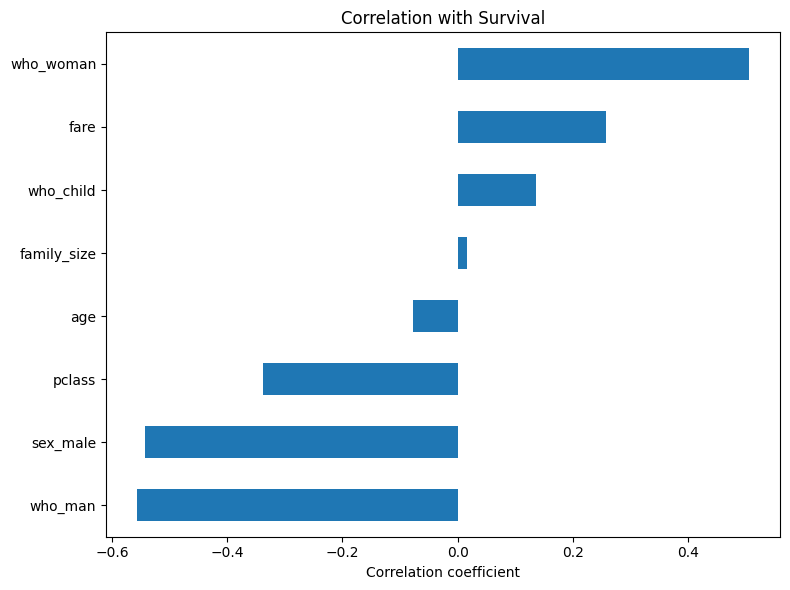

In [220]:
#visualize it as a heat map
survived_corr = full_corr['survived'].drop('survived').sort_values()

plt.figure(figsize=(8, 6))
survived_corr.plot(kind='barh')
plt.title('Correlation with Survival')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

## Summary

Using the Titanic dataset from seaborn I wanted to find what predicted survival on the Titanic using exploratory analysis and Machine Learning methods.

The data from seaborn contained information on 891 passengers aboard the Titanic. Though most of the data was complete, features such as age and deck contained significant numbers of null values (20% and 77% respectively). To counteract this in the training of the models, deck was split and then given as a bool feature showing true or false for each deck, and age was both left null for the HistGradientBoosting model and predicted and filled using a KNN Imputer for the logistic regression and random forest models.

### Key Findings

**Gender** played the largest role in survival during the Titanic disaster. It was found that the ensembled models gave significant weight to gender when predicting who would survive, and that looking at the raw data showed significantly higher survival rates for women (in first class, 97% of women survived compared to 35% of men, a trend seen across classes). Third class men were the demographic most likely to die, showing a 12% survival rate and accounting for 51% of deaths in this data — much larger than their demographic size of 35% of the ship.

**Family size** interestingly also played a large role in survival, and its effects were non-linear. We saw that both solo travellers and larger families had much lower survival rates when compared to families with 2-4 members (survival rate 58%). This is probably due to the trade-off between having someone to help you and having too many people to look after, with smaller families being in the sweet spot of being able to support each other.

**Fare and deck** looked like they could be meaningful indicators of survival, with higher fares, especially in 1st class, showing a correlation with survival. However, when this was controlled for class and gender, we found that women were paying significantly more than men in first class, and women's survival across all classes was prioritised, so this skewed the data. Within the genders themselves there was very little correlation between ticket price and survival. Deck, on the other hand, did indicate higher survival on decks B, D and E, all above 70%; however, the data was restricted mostly to first class, with over 80% of deck data entries being first class passengers — this limits it as a broader prediction feature across the classes.

**Age** played a role in survival across class and gender, with all groups showing at least a weak negative correlation with survival, meaning younger people were more likely to survive. This was first apparent when we saw the survival percentages split across age categories, with 58% of children (below 12) surviving vs only 28% of seniors (60+). It's unlikely that the suggestion of older women being favoured is strictly down to age, due to first class passengers on average being older and the near-universal survival of first class women. Negative correlations were seen across all other class/gender groups.

### Model Performance

All models performed well, at around 80% accuracy. The most accurate model was in fact the simpler logistic regression, input with predicted ages from the KNN Imputer, achieving an accuracy score of 82.1%. The models were then ensembled into a Voting Classifier and their feature importances were calculated. Gender was by far the most important feature, which agrees with the results of the analysis. It was followed by class, age, and then fare price. In this case it is clear to see that fare price is a proxy of both gender and class, as fares tended to be higher for women and higher for higher classes, both groups that saw increased survival chances. The age importance highlights that age did in fact play a role, but the model suggests that gender and class were far more important. The modelling provided support to the analysis and highlighted areas of importance.

### Model Failures

The model failed to predict survival outcomes in a few interesting individual cases. Nearly all unexpected survivors were men (80%), and unexpected deaths were women (83%), showing that it used gender as a near-deterministic rule for survival chances. There was a 57-year-old woman in 2nd class who was predicted a survival chance of 95% who in fact died, and a third class 44-year-old man who was predicted a 92% chance of death who survived. This shows the variable nature of disasters and highlights that there will always be outliers in exceptional circumstances.

### Conclusion

Survival was primarily decided by social position, e.g. gender, class, age, rather than factors such as fare and cabin location. This reflects the "women and children first" evacuation norm combined with stark class inequality on board the ship.